<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Content-based Course Recommender System Using User Profile and Course Genres**


## **Introduction**

Content-based recommendation systems suggest items to users based on their interests and past behavior. One common method is to construct a user profile that represents the user's preferences. This profile is built from the user's previous interactions, such as ratings or enrollments.

To build a content-based recommendation system, each item must first be represented by a set of features that describe its content. These features may include genres such as Python, Database, or Machine Learning or other descriptive information (BoW feature in the previous labs). By using these features together with user ratings, we can create a numerical representation of the user's preferences, called a **user profile vector**.
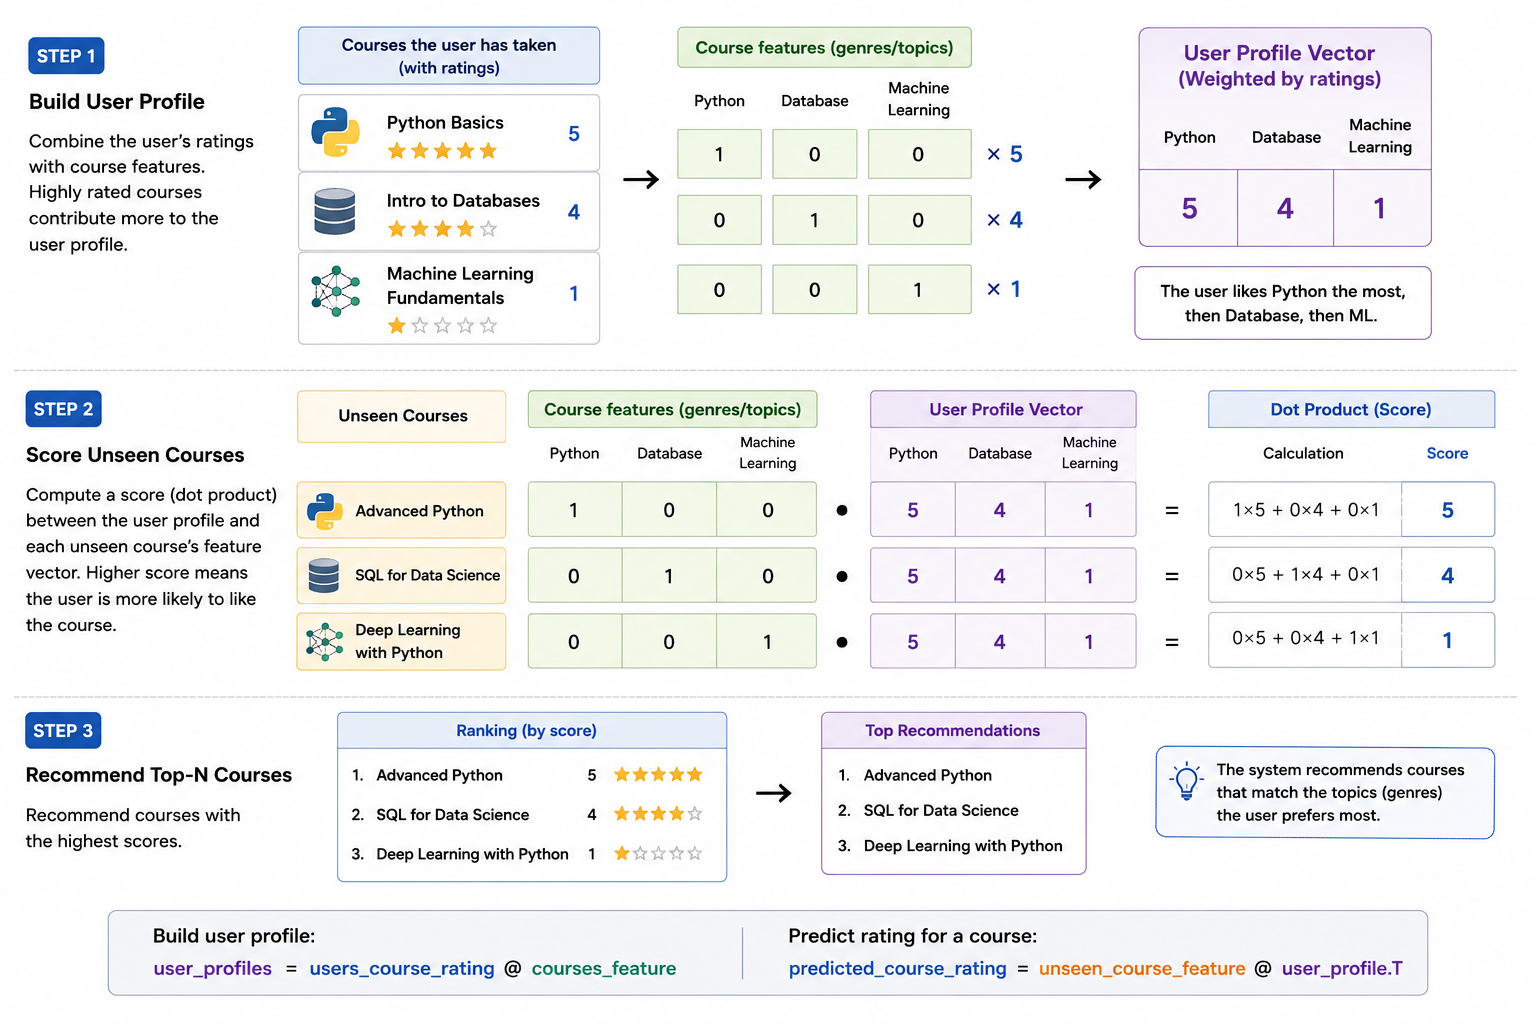

The **user profile** combines the **user's ratings** with the **genre features** of the courses the user has taken. In other words, genres from highly rated courses receive larger weights, so the user profile reflects which topics the user prefers with feature scores.
**`user_profiles` = `users_course_rating` @ `courses_feature`**

Once the user profile is created, we can use it on the genre vectors of new or unseen courses. By computing a predicted course rating score (using a dot product) between the user profile and an unseen course genre vector, we can estimate how much the user may like each course and generate personalized recommendations. **`predicted_course_rating` = `unseen_course_feature` @ `user_profile`.T**


## **Objectives**


* Generate a user profile based on course genres and rating
* Generate course recommendations based on a user's profile and course genres


----


### **Prepare and setup the lab environment**


First, let's install and import the required packages.


In [725]:
# %pip install scikit-learn
# %pip install pandas

In [726]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [727]:
# also set a random state
rs = 123

### **Build user profiles using course genres and ratings**


#### **1. `courses_df` describes the courses (genre features)**

Suppose we have a simple course genre dataset that contains only three genres: `Python`, `Database`, and `Machine Learning`.

Assume there are two courses, `Machine Learning with Python` and `SQL Learning with Python`, and each course is labeled with the genres it belongs to, as illustrated below.


In [728]:
course_genres = ['Python', 'Database', 'MachineLearning']
courses = [['Machine Learning with Python', 1, 0, 1], ["SQL with Python", 1, 1, 0]]
courses_df = pd.DataFrame(courses, columns = ['Title'] + course_genres)
courses_df

,Title,Python,Database,MachineLearning
0,Machine Learning with Python,1,0,1
1,SQL with Python,1,1,0


As we can see from the dataset:
- Each row = one course
- Each column = one genre feature
- 1 means the course has that genre
- 0 means it does not


#### **2. `users_df` describes user behavior (ratings / enrollments)**

In [729]:
users = [['user0', 'Machine Learning with Python', 3], ['user1', 'SQL with Python', 2]]
users_df = pd.DataFrame(users, columns = ['User', 'Title', 'Rating'])
users_df

,User,Title,Rating
0,user0,Machine Learning with Python,3
1,user1,SQL with Python,2


**user0** rated `Machine Learning with Python` as 3 (completed with a certificate)  and **user1** rated `SQL with Python` as 2 (just audited or not completed).

- Each row = one user–course interaction
- Rating = how much user likes the course

Pivot form of `users_df` is the user-course matrix.

In [730]:
users_df.pivot(index="Title", columns="User", values="Rating")

User,user0,user1
Title,,
Machine Learning with Python,3.0,NaN
SQL with Python,NaN,2.0


#### **3. `profiles_df` is the user profile matrix**
It tells how much each user likes each genre (feature)

Intuitively, since user0 has completed the course `Machine Learning with Python`, they should be interested in those genres associated with the course, i.e.,Machine Learning and Python. 

On the other hand, user0 has not taken the `SQL with Python` so it is likely they are not interested in the database genre.


To quantify such user interests, we could multiply user0's rating vector with a course genre matrix and get the weighted genre's vector for the courses:

**`profiles_df` = `users_df` @ `courses_df`**

In [731]:
# User 0 rated course 0 as 3 and course 1 as 0/NA (unknown or not interested)
u0 = np.array([[3, 0]])

In [732]:
# The course genre's matrix
C = courses_df[['Python', 'Database', 'MachineLearning']].to_numpy()

In [733]:
C

array([[1, 0, 1],
       [1, 1, 0]])

Before multiple them, let's first print their shapes:


In [734]:
print(f"User profile vector shape {u0.shape} and course genre matrix shape {C.shape}")

User profile vector shape (1, 2) and course genre matrix shape (2, 3)


If we multiple a $1 x 2$ vector with a $2 x 3$ matrix, we will get a 1 x 3 vector representing the user profile vector.


$$u_0C = \begin{bmatrix} 3 & 0 \end{bmatrix} \begin{bmatrix} 1 & 0 & 1 \\\\\\\\ 1 & 1 & 0 \end{bmatrix}$$


In [735]:
u0_weights = np.matmul(u0, C)
u0_weights

array([[3, 0, 3]])

In [736]:
course_genres

['Python', 'Database', 'MachineLearning']

Let's take a look at the result. This `u0_weights` is also called the weighted genre vector and represents the interests of the user for each genre based on the courses they have rated. As we can see from the results, user0 seems interested in `Python` and `MachineLearning` with a rating of 3.


Similarly, we can calculate the weighted genre matrix for user 1:


$$u_1C = \begin{bmatrix} 0 & 2 \end{bmatrix} \begin{bmatrix} 1 & 0 & 1 \\\\\\\\ 1 & 1 & 0 \end{bmatrix}$$


In [737]:
# User 1 rated course 0 as 0 (unknown or not interested) and course 1 as 2
u1 = np.array([[0, 2]])

In [738]:
u1_weights = np.matmul(u1, C)  # the same as np.dot(u1, C) or u1 @ C
u1_weights

array([[2, 2, 0]])

As we can see from the `u1_weights` vector, user1 seems very interested in `Python` and `Database` with a value 2.


Let's combine the two weighted genre vectors and create a user profile dataframe:

**`profiles_df` = `users_df` @ `courses_df`**


In [739]:
weights = np.concatenate((u0_weights.reshape(1, 3), u1_weights.reshape(1, 3)), axis=0)
profiles_df = pd.DataFrame(weights, columns=['Python', 'Database', 'MachineLearning'])
profiles_df.insert(0, 'user', ['user0', 'user1'])

In [740]:
profiles_df

,user,Python,Database,MachineLearning
0,user0,3,0,3
1,user1,2,2,0


Now this `profiles_df` clearly shows the user profiles or course interests, we can see that `user0` is very interested in Python and machine learning, and `user1` is very interested in Python and database.

### **Generate recommendation scores for some new courses**


In the previous section, we generated user profile vectors by combining user ratings with course genre vectors. The resulting table, profile_df, stores the preference weights of each user for every genre.

In this section, we use these user profiles to predict ranking scores from users on new courses. 

#### **1. `new_courses_df` describes the new courses (genre features)**


Now, suppose we published some new courses titled as `Python 101`, `Database 101`, and `Machine Learning with R`:


In [741]:
new_courses = [['Python 101', 1, 0, 0], ["Database 101", 0, 1, 0], ["Machine Learning with R", 0, 0, 1]]
new_courses_df = pd.DataFrame(new_courses, columns = ['Title', 'Python', 'Database', 'MachineLearning'])
new_courses_df

,Title,Python,Database,MachineLearning
0,Python 101,1,0,0
1,Database 101,0,1,0
2,Machine Learning with R,0,0,1


Let's convert the course genre dataframe into a 2-D numpy array:


In [742]:
# Drop the title column
new_courses_df = new_courses_df.loc[:, new_courses_df.columns != 'Title']
course_matrix = new_courses_df.values
course_matrix

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [743]:
# course matrix shape
course_matrix.shape

(3, 3)

As we can see from the above output, the course matrix is a `3 x 3` matrix and each row vector is a course genre vector.


#### **2. `profiles_df` describes how much each user likes each genre (feature)**

Then we can convert the user profile dataframe into another 2-d numpy array:


In [744]:
profiles_df

,user,Python,Database,MachineLearning
0,user0,3,0,3
1,user1,2,2,0


In [745]:
# Drop the user column
profiles_df = profiles_df.loc[:, profiles_df.columns != 'user']
profile_matrix = profiles_df.values
profile_matrix

array([[3, 0, 3],
       [2, 2, 0]])

In [746]:
profile_matrix.shape

(2, 3)

The profile matrix is a 2 x 3 matrix and each row is a user profile vector:


#### **3. `scores_df` is the predicted version of pivot(`users_df`)**

pivot(`users_df`) contains the real ratings given by users to courses.

`scores_df` contains the predicted ratings computed by the model.

We have build user profiles, in which each user is described by how much they like each genre. 

**`profiles_df` = `users_df` @ `courses_df`**
- users_df (pivot form) = user × course
- courses_df = course × genre
- profiles_df = user × genre

Then we compute recommendation scores:

**`scores` = `new_course_matrix` @ `profile_matrix`.T** 
- new_course_matrix = course × genre
- profile_matrix.T = genre × user
- scores = course × user
  
`scores` has the same structure as pivot(`users_df`)
```
scores = new_course_matrix @ (users_df @ courses_df).T
       = new_course_matrix @ courses_df.T @ users_df.T
```
The result ends with `users_df`.T (which has the same layout as pivot(`users_df`)),
`scores_df` also has the same structure (course × user), but the values are predicted scores, not real ratings         

In [747]:
scores = np.matmul(course_matrix, profile_matrix.T)
scores

array([[3, 2],
       [0, 2],
       [3, 0]])

Now let's add the course titles and user ids back to make the results more clear:


In [748]:
scores_df = pd.DataFrame(scores, columns=['User0', 'User1'])
scores_df.index = ['Python 101', 'Database 101', 'Machine Learning with R']

In [749]:
# recommendation score dataframe
scores_df

,User0,User1
Python 101,3,2
Database 101,0,2
Machine Learning with R,3,0


From the score results, we can see that:
- For user0, the recommended courses are `Python 101` and `Machine Learning with R` because user0 is very interested in Python and machine learning
- For user1, the recommended courses are `Python 101` and `Database 101` because user1 seems very interested in topics like Python and database


### **Generate course recommendations based on user profile and course genre vectors**


In the previous section, we generated user profile vectors by combining user ratings with course genre vectors. The resulting table, `profile_df`, stores the preference weights of each user for every genre.

In this section, we use these user profiles to generate course recommendations based on content similarity.

#### **1. `course_genres_df` — course feature matrix**

- each row = one course
- each column = one genre
- 1 = course has this genre
- 0 = does not

In [750]:
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
course_genres_df = pd.read_csv(course_genre_url)

In [751]:
course_genres_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


#### **2. `profile_df` — user profile vectors computed earlier**

- each row = one user
- each column = interest weight for a genre

In [752]:
profile_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv"
profile_df = pd.read_csv(profile_genre_url)

In [753]:
profile_df.head()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


The profile dataframe contains the course interests for each user, for example, user 8 is very interested in R, data analysis, database, and big data:


In [754]:
profile_df[profile_df['user'] == 8]

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


#### **3. `test_users_df` — describes what courses the user has already enrolled**

Next, let's load a test dataset, contains the test users and the courses they have already enrolled in (or interacted with):
This dataframe is not used to build user profiles. Instead, it is used to:
- determine which users need recommendations, and
- identify the courses already known to each user, so that we do not recommend them again.

In [755]:
#test_users_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
test_users_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/rs_content_test.csv"
test_users_df = pd.read_csv(test_users_url)

In [756]:
test_users_df.head()

,user,item,rating
0,1502801,RP0105EN,3.0
1,1609720,CNSC02EN,2.0
2,1347188,CO0301EN,3.0
3,755067,ML0103EN,3.0
4,538595,BD0115EN,3.0


Let's look at how many test users we have in the dataset.


In [757]:
# Group the test users DataFrame by the 'user' column and find the maximum value for each group,
# then reset the index and drop the old index to obtain a DataFrame with unique user IDs
test_users = test_users_df.groupby(['user']).max().reset_index(drop=False)

# Extract the 'user' column from the test_users DataFrame and convert it to a list of user IDs
test_user_ids = test_users['user'].to_list()

# Print the total number of test users by obtaining the length of the test_user_ids list
print(f"Total numbers of test users {len(test_user_ids)}")


Total numbers of test users 1000


Then for each test user in the test dataset, you need to first find out which courses are unknown/unselected to them. For example, suppose we have a user `1078030` with profile:


In [758]:
test_user_profile = profile_df[profile_df['user'] == 1078030]
test_user_profile

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
18204,1078030,0.0,12.0,0.0,9.0,0.0,12.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0


In [759]:
# Now let's get the test user vector by excluding the `user` column
test_user_vector = test_user_profile.iloc[0, 1:].values
test_user_vector

array([ 0., 12.,  0.,  9.,  0., 12.,  0.,  6.,  0.,  0.,  0.,  0.,  0.,
        0.])

#### **4. Create `courses_df` with unknown courses the users did not take**
We can first find their enrolled courses in `test_users_df`:


In [760]:
enrolled_courses = test_users_df[test_users_df['user'] == 1078030]['item'].to_list()
enrolled_courses = set(enrolled_courses) # gets the courses this user already knows

In [761]:
enrolled_courses

{'DA0101EN',
 'DV0101EN',
 'ML0101ENv3',
 'ML0115EN',
 'ML0120ENv2',
 'ML0122ENv1',
 'PY0101EN',
 'ST0101EN'}

We then print the entire course list:


In [762]:
all_courses = set(course_genres_df['COURSE_ID'].values) 

Then we can use all courses to subtract the enrolled courses to get a set of all unknown courses for user `1078030`, and we want to find potential interested courses hidden in the unknown course list.


In [763]:
unknown_courses = all_courses.difference(enrolled_courses)
unknown_courses # all courses minus already enrolled courses

{'AI0111EN',
 'BC0101EN',
 'BC0201EN',
 'BC0202EN',
 'BD0101EN',
 'BD0111EN',
 'BD0115EN',
 'BD0121EN',
 'BD0123EN',
 'BD0131EN',
 'BD0133EN',
 'BD0135EN',
 'BD0137EN',
 'BD0141EN',
 'BD0143EN',
 'BD0145EN',
 'BD0151EN',
 'BD0153EN',
 'BD0211EN',
 'BD0212EN',
 'BD0221EN',
 'BD0223EN',
 'BENTEST4',
 'CB0101EN',
 'CB0103EN',
 'CB0105ENv1',
 'CB0201EN',
 'CC0101EN',
 'CC0103EN',
 'CC0120EN',
 'CC0121EN',
 'CC0150EN',
 'CC0201EN',
 'CC0210EN',
 'CC0250EN',
 'CC0271EN',
 'CL0101EN',
 'CNSC02EN',
 'CO0101EN',
 'CO0193EN',
 'CO0201EN',
 'CO0301EN',
 'CO0302EN',
 'CO0401EN',
 'COM001EN',
 'CP0101EN',
 'DA0151EN',
 'DA0201EN',
 'DAI101EN',
 'DB0101EN',
 'DB0111EN',
 'DB0113EN',
 'DB0115EN',
 'DB0151EN',
 'DE0205EN',
 'DJ0101EN',
 'DP0101EN',
 'DS0101EN',
 'DS0103EN',
 'DS0105EN',
 'DS0107',
 'DS0110EN',
 'DS0132EN',
 'DS0201EN',
 'DS0301EN',
 'DS0321EN',
 'DV0151EN',
 'DW0101EN',
 'DX0106EN',
 'DX0107EN',
 'DX0108EN',
 'EE0101EN',
 'GPXX01AVEN',
 'GPXX01DCEN',
 'GPXX01RYEN',
 'GPXX03HFEN',
 'GP

We can get the genre vectors for those unknown courses as well:


In [764]:
unknown_course_genres = course_genres_df[course_genres_df['COURSE_ID'].isin(unknown_courses)]
# Now let's get the course matrix by excluding `COURSE_ID` and `TITLE` columns:
course_matrix = unknown_course_genres.iloc[:, 2:].values # drop the first two columns
course_matrix

array([[0, 0, 0, ..., 1, 1, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 1, 1, 0]])

Given the user profile vector for user `1078030`  and all the unseen course genres vectors above, you can use the dot product to calculate the recommendation score for each unknown course. e.g., the recommendation score for course `accelerating deep learning with gpu` is:


#### **5. Compute recommendation scores**

In [765]:
score = np.dot(course_matrix[1], test_user_vector) # Dot product of two vectors
score

30.0

Later, we will need to choose a recommendation score threshold. If the score of any course is above the threshold, we may recommend that course to the user.


The workflow can be summarized in the following flowchart:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_3/images/recommend_courses.png)


Next, let's calculate the recommendation scores of all courses for all the 1000 test users. 


In [766]:
# Reload the test users dataset from the specified URL using pandas and store it in test_users_df
test_users_df = pd.read_csv(test_users_url)

# Reload the user profiles dataset from the specified URL containing user profiles and their associated genres using pandas and store it in profile_df
profile_df = pd.read_csv(profile_genre_url)

# Reload the course genres dataset from the specified URL containing course genres using pandas and store it in course_genres_df
course_genres_df = pd.read_csv(course_genre_url)

# Create an empty dictionary to store the results of the recommendation process
res_dict = {}


We only want to recommend courses with very high scores so we may set a score threshold to filter out those courses with low scores.


#### **6. Combine all steps in to a function**
We defined a function called `generate_recommendation_scores()` to compute the recommendation scores of all the unknown courses for all test users.


_TODO: Complete the generate_recommendation_scores() function blow to generate recommendation score for all users. You may also implement the task with different solutions._


In [767]:
def generate_recommendation_scores():
    """
    Generate recommendation scores for users and courses.

    Returns:
    users (list): List of user IDs.
    courses (list): List of recommended course IDs.
    scores (list): List of recommendation scores.
    """

    users = []      # List to store user IDs
    courses = []    # List to store recommended course IDs
    scores = []     # List to store recommendation scores

    # Iterate over each user ID in the test_user_ids list
    for user_id in test_user_ids:
        # Get the user profile data for the current user
        test_user_profile = profile_df[profile_df['user'] == user_id]

        # Get the user vector for the current user id
        test_user_vector = test_user_profile.iloc[0, 1:].values

        # Get the known course ids for the current user
        enrolled_courses = test_users_df[test_users_df['user'] == user_id]['item'].to_list()

        # Calculate the unknown course ids
        unknown_courses = all_courses.difference(enrolled_courses)

        # Filter the course_genres_df to include only unknown courses
        unknown_course_df = course_genres_df[course_genres_df['COURSE_ID'].isin(unknown_courses)]
        unknown_course_ids = unknown_course_df['COURSE_ID'].values

        # Calculate the recommendation scores using dot product
        recommendation_scores = np.dot(unknown_course_df.iloc[:, 2:].values, test_user_vector)

        # Append the results into the users, courses, and scores list
        for i in range(0, len(unknown_course_ids)):
            score = recommendation_scores[i]

            # Only keep the courses with high recommendation score
            if score >= score_threshold:
                users.append(user_id)
                courses.append(unknown_course_ids[i])
                scores.append(recommendation_scores[i])

    return users, courses, scores
 


In [768]:
# Create a list of threshold values ranging from 10 to 30 with a step of 2
threshold_list = list(range(10,30,2))

results = []

for t in threshold_list:
    score_threshold = t
    # Call the generate_recommendation_scores function to obtain recommendation scores for users and courses,
    # and assign the returned lists to variables users, courses, and scores
    users, courses, scores = generate_recommendation_scores()
    
    # Create a DataFrame named res_df using the users, courses, and scores lists, with columns 'USER', 'COURSE_ID', and 'SCORE'
    res_df = pd.DataFrame({
        'USER': users,
        'COURSE_ID': courses,
        'SCORE': scores
    })
    
    # Count recommendations per user
    counts = res_df.groupby('USER').size()
    
    results.append({
        'threshold': t,
        'avg_rec': counts.mean(),
        'max_rec': counts.max(),
        'pct_hit_20': (counts == 20).mean()
    })

pd.DataFrame(results)

,threshold,avg_rec,max_rec,pct_hit_20
0,10,61.818287,267,0.003472
1,12,61.285880,267,0.004630
2,14,43.628892,237,0.006227
3,16,34.635977,224,0.016997
4,18,34.336170,224,0.021277
5,20,28.131313,221,0.028620
6,22,24.159836,132,0.059426
7,24,23.969072,132,0.057732
8,26,20.714646,115,0.063131
9,28,19.223301,93,0.097087


In [ ]:
# Set the recommendation score threshold to 18, which give the average recommendation per user around 20.
score_threshold = 18 

# Call the generate_recommendation_scores function to obtain recommendation scores for users and courses,
# and assign the returned lists to variables users, courses, and scores
users, courses, scores = generate_recommendation_scores()
    
# Create a DataFrame named res_df using the users, courses, and scores lists, with columns 'USER', 'COURSE_ID', and 'SCORE'
res_df = pd.DataFrame({
    'USER': users,
    'COURSE_ID': courses,
    'SCORE': scores
    })

res_df

,USER,COURSE_ID,SCORE
0,37465,RP0105EN,27.0
1,37465,BD0145EN,24.0
2,37465,TMP0105EN,27.0
3,37465,BD0212EN,27.0
4,37465,SC0103EN,27.0
...,...,...,...
24202,2087663,excourse70,18.0
24203,2087663,excourse71,18.0
24204,2087663,excourse72,21.0
24205,2087663,excourse73,21.0


**NOTE**: Instead of using some absolute score threshold, you may also try sorting the scores for each user and return the top-ranked courses.


In [866]:
def generate_recommendation_scores_2(top_n=20):
    """
    Generate recommendation scores using top-N ranking instead of threshold.

    Returns:
    users (list): List of user IDs
    courses (list): List of recommended course IDs
    scores (list): List of recommendation scores
    """

    users = []
    courses = []
    scores = []

    for user_id in test_user_ids:

        # Get user vector
        test_user_profile = profile_df[profile_df['user'] == user_id]
        test_user_vector = test_user_profile.iloc[0, 1:].values

        # Known courses
        enrolled_courses = test_users_df[
            test_users_df['user'] == user_id
        ]['item'].to_list()

        # Unknown courses
        unknown_courses = all_courses.difference(enrolled_courses)

        unknown_course_df = course_genres_df[
            course_genres_df['COURSE_ID'].isin(unknown_courses)
        ]

        unknown_course_ids = unknown_course_df['COURSE_ID'].values

        # Compute scores
        recommendation_scores = np.dot(
            unknown_course_df.iloc[:, 2:].values,
            test_user_vector
        )

        # ✅ Build temp dataframe
        temp_df = pd.DataFrame({
            'COURSE_ID': unknown_course_ids,
            'score': recommendation_scores
        })

        # ✅ Sort by score (highest first)
        temp_df = temp_df.sort_values(by='score', ascending=False)

        # ✅ Select top N (instead of threshold)
        temp_df = temp_df.head(top_n)

        # Store results
        for _, row in temp_df.iterrows():
            users.append(user_id)
            courses.append(row['COURSE_ID'])
            scores.append(row['score'])

    return users, courses, scores

After you have completed the function `generate_recommendation_scores()` above, you can test it and generate recommendation scores and save the courses recommendations into a dataframe with three columns: `USER`, `COURSE_ID`, `SCORE`:


In [867]:
# Call the generate_recommendation_scores function to obtain recommendation scores for users and courses,
# and assign the returned lists to variables users, courses, and scores
users, courses, scores = generate_recommendation_scores_2(top_n=20)
    
# Create a DataFrame named res_df using the users, courses, and scores lists, with columns 'USER', 'COURSE_ID', and 'SCORE'
res_df_2 = pd.DataFrame({
    'USER': users,
    'COURSE_ID': courses,
    'SCORE': scores
    })

res_df_2


,USER,COURSE_ID,SCORE
0,37465,excourse31,27.0
1,37465,TMP0105EN,27.0
2,37465,excourse73,27.0
3,37465,RP0105EN,27.0
4,37465,SC0103EN,27.0
...,...,...,...
19995,2087663,CO0301EN,26.0
19996,2087663,GPXX0TY1EN,26.0
19997,2087663,CC0210EN,26.0
19998,2087663,DS0201EN,26.0


With the course recommendation list generated for each test user, we  need to perform some analytic tasks to answer the following two questions:


- On average, how many new courses have been recommended per test user?
- What are the most frequently recommended courses? Return the top-10 commonly recommended courses across all test users.


For example, suppose we have only 3 test users, each user receives the following course recommendations:


- User1: ['course1', 'course2']
- User2: ['course3', 'course4']
- User3: ['course3', 'course4', 'course5']


Then, the average recommended courses per user is: $(2 + 2 + 3) / 3 = 2.33$. The top-2 recommended courses are: `course3`: 2 times, and `course4`: 2 times.


Note that the answers may depend on your score threshold. A lower score threshold yields more recommended courses but with smaller confidence so that some test users may receive very long course recommendation lists and feel overwhelmed. 

Ideally, we should limit the maximum course recommendations to be less than 20 courses per user. As such, **the average course recommendations per user should also be less than 20 or so**. This makes sure we only recommend relevant courses with high confidence (score).


#### **7. Calculate the average number of new courses recommended per test user**

In [868]:
# caculate the number of test users in the final res_df
res_df.groupby('USER').size().reset_index(name='Count')

,USER,Count
0,37465,25
1,85625,63
2,108541,21
3,149690,29
4,152320,45
...,...,...
700,2050073,1
701,2056952,26
702,2061096,41
703,2074313,46


864 is less than 1000 (all test user number), which means some users got no recommendation. 

In [869]:
# Calculate the average number of recommended courses per test user
# all test users, including those with zero recommendations and not in res_df
all_test_users = test_users_df['user'].unique()
recommendation_counts = res_df.groupby('USER')['COURSE_ID'].nunique()
recommendation_counts = recommendation_counts.reindex(all_test_users, fill_value=0)

# Print the result
average_courses_per_user = recommendation_counts.mean()
print("Average number of new courses recommended per test user:", average_courses_per_user)

Average number of new courses recommended per test user: 24.207


In [870]:
recommendation_counts.head()

USER
1502801    61
1609720     4
1347188     4
755067      9
538595     65
Name: COURSE_ID, dtype: int64

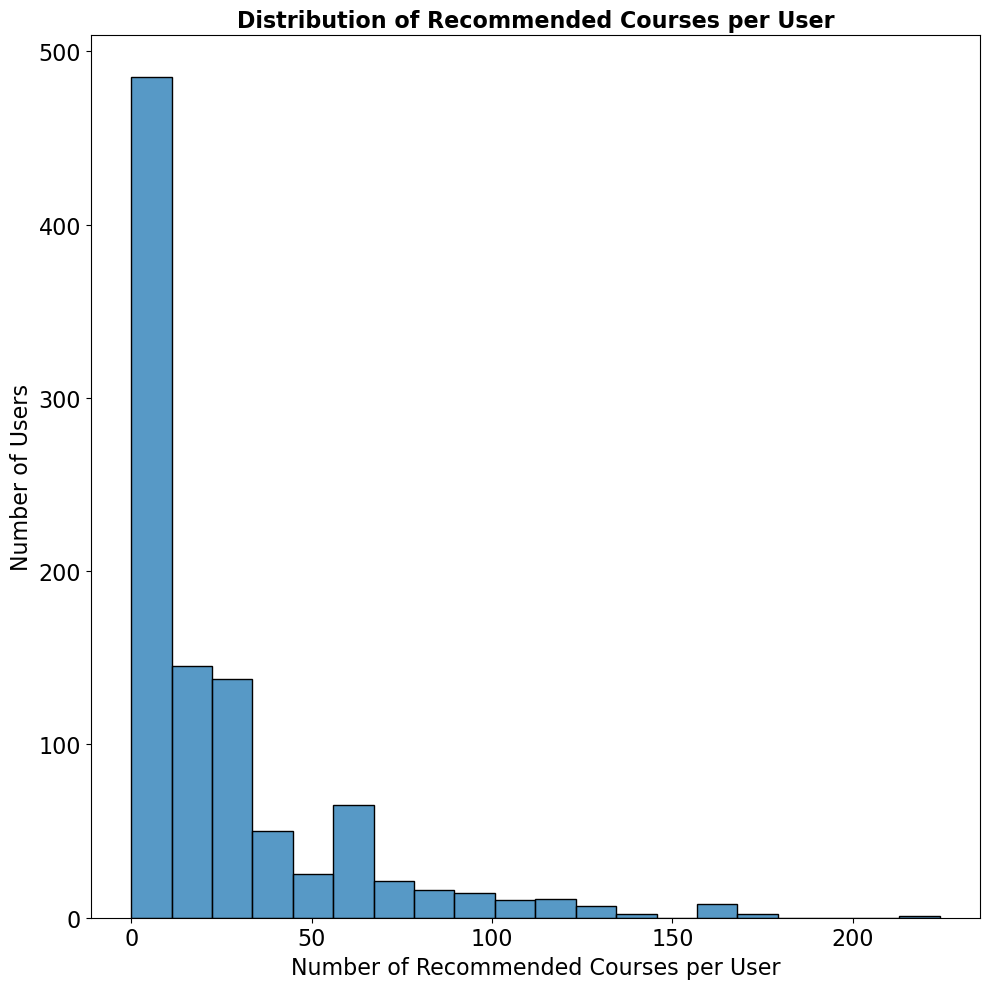

In [871]:
plt.figure(figsize=(10, 10))
sns.histplot(recommendation_counts, bins=20)
plt.xlabel("Number of Recommended Courses per User", fontsize=16)
plt.ylabel("Number of Users", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Distribution of Recommended Courses per User", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

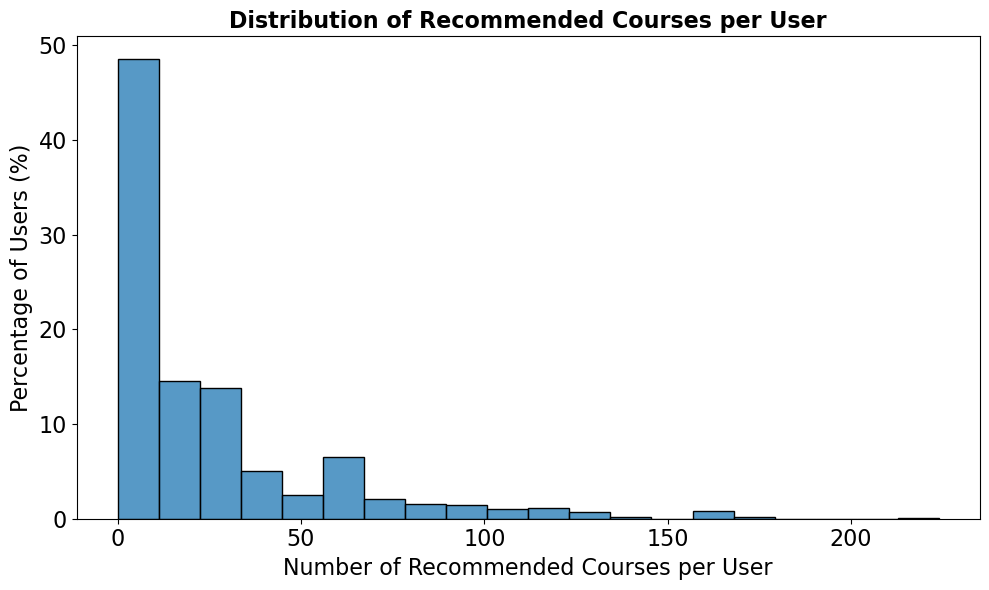

In [872]:
plt.figure(figsize=(10, 6))

sns.histplot(
    recommendation_counts,
    bins=20,
    stat="percent"   # 👈 THIS is the key
)

plt.xlabel("Number of Recommended Courses per User", fontsize=16)
plt.ylabel("Percentage of Users (%)", fontsize=16)
plt.title("Distribution of Recommended Courses per User", fontsize=16, fontweight='bold')
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

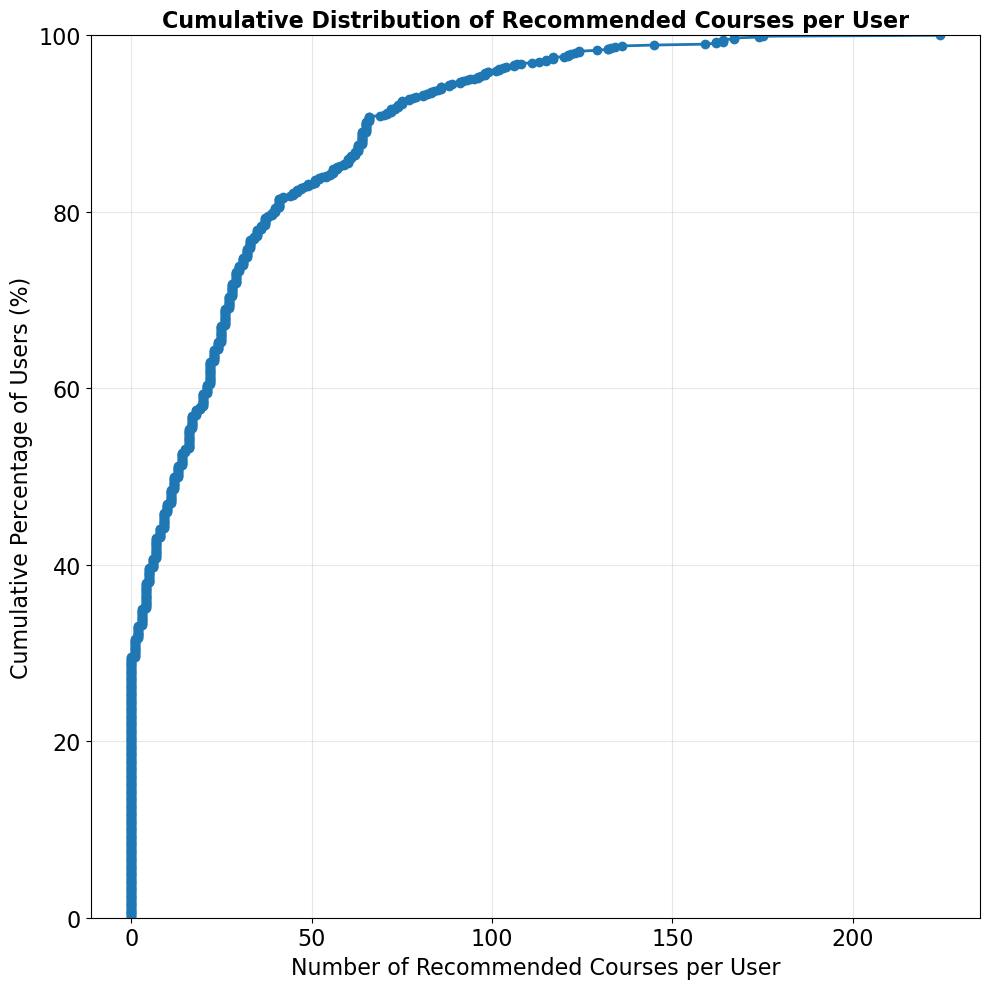

In [873]:
plt.figure(figsize=(10, 10))
sorted_counts = np.sort(recommendation_counts)
cumulative_pct = (np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)) * 100
plt.plot(sorted_counts, cumulative_pct, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Number of Recommended Courses per User", fontsize=16)
plt.ylabel("Cumulative Percentage of Users (%)", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Cumulative Distribution of Recommended Courses per User", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim([0, 100])
plt.tight_layout()
plt.show()

#### **8. Determine the most frequently recommended courses across all test users**

In [874]:
# Find the top 10 most frequently recommended courses
top_10_courses = (
    res_df.groupby('COURSE_ID')
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
    .head(10)
)
# Print the result with added column description
print("Top 10 most frequently recommended courses:")
print(top_10_courses)

Top 10 most frequently recommended courses:
      COURSE_ID  Count
213  excourse22    364
212  excourse21    364
191    TA0106EN    364
163    ML0122EN    361
261  excourse72    360
179    RP0105EN    360
262  excourse73    360
193   TMP0105EN    356
222  excourse31    353
181    SC0103EN    329


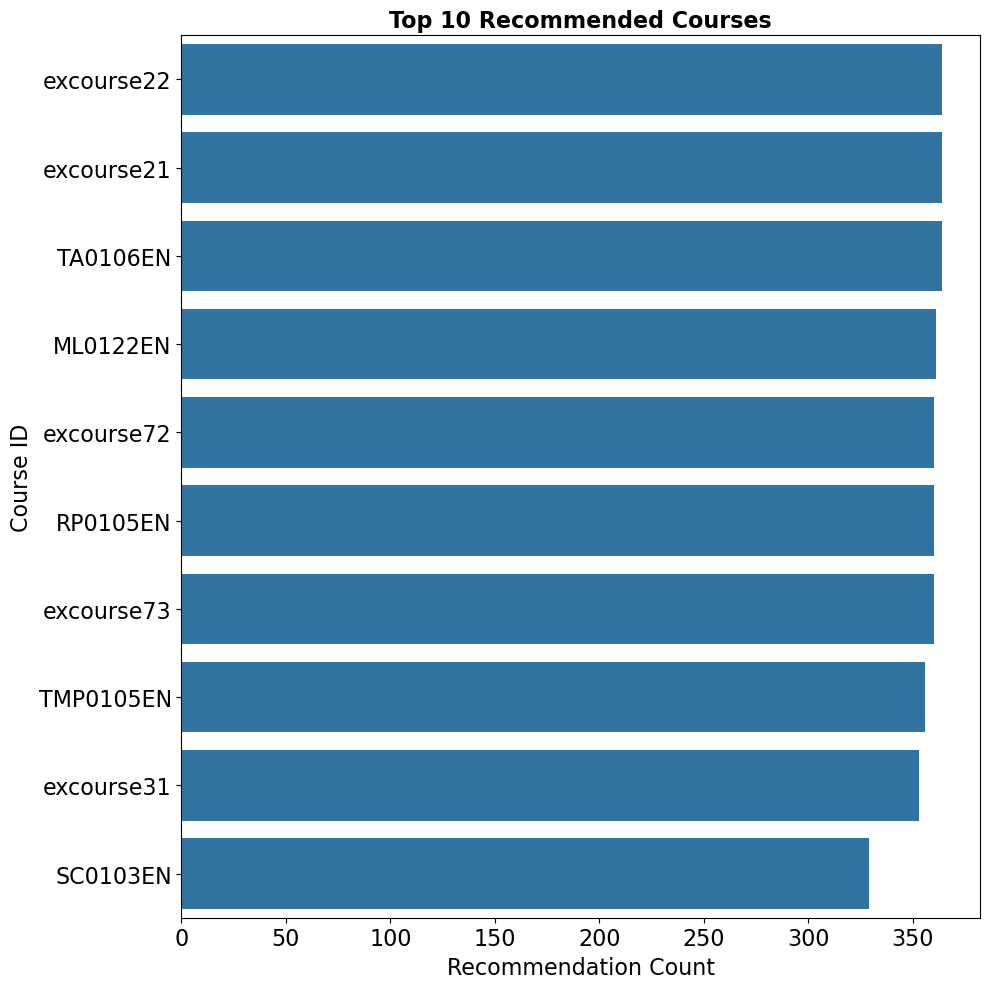

In [875]:
plt.figure(figsize=(10, 10))
sns.barplot(data=top_10_courses, x='Count', y='COURSE_ID')
plt.xlabel("Recommendation Count", fontsize=16)
plt.ylabel("Course ID", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Top 10 Recommended Courses", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


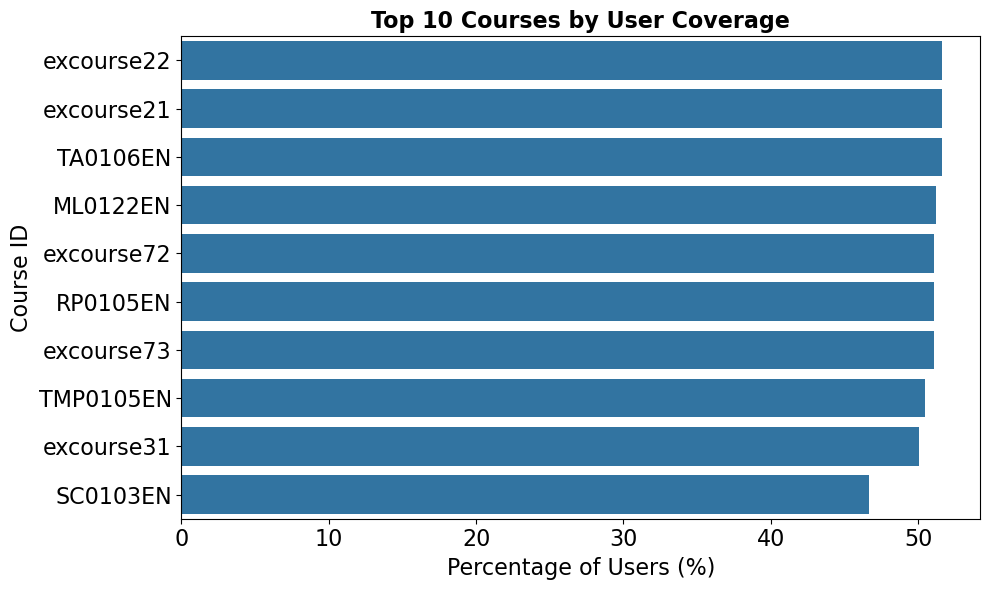

In [876]:
course_user_counts = res_df.groupby('COURSE_ID')['USER'].nunique()
total_users = res_df['USER'].nunique()
course_user_percentage = (course_user_counts / total_users) * 100
top10_pct = course_user_percentage.sort_values(ascending=False).head(10)
top10_pct_df = top10_pct.reset_index()
top10_pct_df.columns = ['COURSE_ID', 'USER_PERCENT']

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_pct_df,
    x='USER_PERCENT',
    y='COURSE_ID'
)

plt.xlabel("Percentage of Users (%)", fontsize=16)
plt.ylabel("Course ID", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Top 10 Courses by User Coverage", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Summary**


In this lab, we first generated a user profile vector based on the user's course ratings and course genre vectors. Then, with the user profile generated, we applied a simple dot product between the user profile vector and the course genre vector to generate a course recommendation score. 

The idea is if a user is interested in certain topics (genres) and if a course also has similar topics (genres), which means the user vector and course genre vector share common dimensions, and a dot product is able to capture such similarity.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu
